<a href="https://colab.research.google.com/github/Anikettcoder/ResQVision/blob/feature%2Fdata_preparation/notebooks/01_Data_Preparation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [53]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [54]:
import os                                                                    #File and folder management

PROJECT_DIR = "/content/drive/MyDrive/ResQVision"

print("Does the project folder exist?")
print(os.path.exists(PROJECT_DIR))

Does the project folder exist?
True


*Now that we know the folder exists, let's see what's inside*

In [55]:
print(os.listdir(PROJECT_DIR))

['Datasets', 'Models', 'Notebooks', 'Outputs', 'Docs', 'References', 'Assets', 'Presentation']


### Import the Libraries We Need

In [56]:
import glob                                                        # Helps us find files using patterns.
import shutil                                                      # This is used for file operations.(copy, move, delete dir)
import random                                                      # We need this because later we'll randomly select images.

import cv2                                                    # Reading & Resizing images, Drawing bounding boxes, Image & Video processing
import numpy as np                                            # image dimensions, numerical calculations, bounding-box calculations, statistics
import pandas as pd                                           # annotation analysis, experiment results
import matplotlib.pyplot as plt

In [57]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

PyTorch version: 2.11.0+cu128
CUDA available: True


In [58]:
# Dataset folders
DATASET_DIR = os.path.join(PROJECT_DIR, "Datasets")

RAW_DIR = os.path.join(DATASET_DIR, "Raw")

PROCESSED_DIR = os.path.join(DATASET_DIR, "Processed")

# Output folder
OUTPUT_DIR = os.path.join(PROJECT_DIR, "Outputs")

print("Project:", PROJECT_DIR)
print("Raw datasets:", RAW_DIR)
print("Processed datasets:", PROCESSED_DIR)
print("Outputs:", OUTPUT_DIR)

Project: /content/drive/MyDrive/ResQVision
Raw datasets: /content/drive/MyDrive/ResQVision/Datasets/Raw
Processed datasets: /content/drive/MyDrive/ResQVision/Datasets/Processed
Outputs: /content/drive/MyDrive/ResQVision/Outputs


### Create visdrone path

In [59]:
VISDRONE_DIR = os.path.join(RAW_DIR, "VisDrone")

print("VisDrone directory:")
print(VISDRONE_DIR)

VisDrone directory:
/content/drive/MyDrive/ResQVision/Datasets/Raw/VisDrone


### File Structure

In [60]:
print("Files currently inside VisDrone folder:")

for item in os.listdir(VISDRONE_DIR):
    print("-", item)

Files currently inside VisDrone folder:
- Object detection in video
- Object detection in image
- Multi-Object tracking


---

### Now we will use the VisDrone Object Detection in Image dataset

In [61]:
VISDRONE_ROOT = os.path.join( RAW_DIR, "VisDrone", "Object detection in image")

print("VisDrone DET path:")
print(VISDRONE_ROOT)

VisDrone DET path:
/content/drive/MyDrive/ResQVision/Datasets/Raw/VisDrone/Object detection in image


In [62]:
print("Contents of VisDrone Object Detection in Image:")

for item in os.listdir(VISDRONE_ROOT):
    print("-", item)

Contents of VisDrone Object Detection in Image:
- VisDrone2019-DET-train
- VisDrone2019-DET-val


Exploring training data & validation data

In [63]:
# Path to VisDrone training dataset
TRAIN_DIR = os.path.join( VISDRONE_ROOT, "VisDrone2019-DET-train" )

# Path to VisDrone validation dataset
VAL_DIR = os.path.join( VISDRONE_ROOT, "VisDrone2019-DET-val" )

print("Training dataset:")
print(TRAIN_DIR)

print("\nValidation dataset:")
print(VAL_DIR)

Training dataset:
/content/drive/MyDrive/ResQVision/Datasets/Raw/VisDrone/Object detection in image/VisDrone2019-DET-train

Validation dataset:
/content/drive/MyDrive/ResQVision/Datasets/Raw/VisDrone/Object detection in image/VisDrone2019-DET-val


In [64]:
print("Contents of training dataset:\n")

for item in os.listdir(TRAIN_DIR):
    print("-", item)
print("\n")
print("Contents of validation dataset:\n")

for item in os.listdir(VAL_DIR):
    print("-", item)

Contents of training dataset:

- annotations
- images


Contents of validation dataset:

- .DS_Store
- images
- annotations


Exploring images

In [65]:
TRAIN_IMAGES_DIR = os.path.join( TRAIN_DIR, "images")

train_images = glob.glob( os.path.join( TRAIN_IMAGES_DIR, "*.jpg" ))
print("Number of train images:", len(train_images))

VAL_IMAGES_DIR = os.path.join( VAL_DIR, "images")

val_images = glob.glob( os.path.join( VAL_IMAGES_DIR, "*.jpg" ))
print("Number of val images:", len(val_images))

Number of train images: 6471
Number of val images: 548


Exploring annotations

In [66]:

TRAIN_ANNOTATIONS_DIR = os.path.join(TRAIN_DIR, "annotations")

train_annotations = glob.glob( os.path.join (TRAIN_ANNOTATIONS_DIR, "*.txt"))
print("Number of val annotations: ", len(train_annotations))


VAL_ANNOTATIONS_DIR = os.path.join(VAL_DIR, "annotations")

val_annotations = glob.glob( os.path.join (VAL_ANNOTATIONS_DIR, "*.txt"))
print("Number of val annotations: ", len(val_annotations))

Number of val annotations:  6471
Number of val annotations:  548


### CLEANING DATA

In [67]:
#FOR TRAINING SET
train_image_names = {
    os.path.splitext(os.path.basename(path))[0]
    for path in train_images
}

train_annotation_names = {
    os.path.splitext(os.path.basename(path))[0]
    for path in train_annotations
}

missing_annotations = ( train_image_names - train_annotation_names
)

extra_annotations = ( train_annotation_names - train_image_names )

print( "Images without annotations:", len(missing_annotations))

print( "Annotations without images:", len(extra_annotations))

Images without annotations: 0
Annotations without images: 0


In [68]:
#FOR VALIDATION SET
val_image_names = {
    os.path.splitext(os.path.basename(path))[0]
    for path in val_images
}

val_annotation_names = {
    os.path.splitext(os.path.basename(path))[0]
    for path in val_annotations
}

missing_val_annotations = ( val_image_names - val_annotation_names )

extra_val_annotations = ( val_annotation_names - val_image_names)

print( "Validation images without annotations:", len(missing_val_annotations))
print( "Validation annotations without images:", len(extra_val_annotations))

Validation images without annotations: 0
Validation annotations without images: 0


In [69]:
from collections import Counter

category_counter = Counter()

for annotation_file in train_annotations:

    with open(annotation_file, "r") as file:

        for line in file:

            values = line.strip().split(",")

            if len(values) >= 6:

                category = int(values[5])

                category_counter[category] += 1

print("Category distribution:")
print(category_counter)

Category distribution:
Counter({4: 144867, 1: 79337, 10: 29647, 2: 27059, 5: 24956, 6: 12875, 3: 10480, 0: 8813, 9: 5926, 7: 4812, 8: 3246, 11: 1532})


In [70]:
# Select the first training image
sample_image = train_images[0]

# Extract only the filename without .jpg
sample_name = os.path.splitext(
    os.path.basename(sample_image)
)[0]

# Create the corresponding annotation path
sample_annotation = os.path.join(
    TRAIN_ANNOTATIONS_DIR,
    sample_name + ".txt"
)

print("Sample image:")
print(sample_image)

print("\nSample annotation:")
print(sample_annotation)

Sample image:
/content/drive/MyDrive/ResQVision/Datasets/Raw/VisDrone/Object detection in image/VisDrone2019-DET-train/images/9999990_00000_d_0000077.jpg

Sample annotation:
/content/drive/MyDrive/ResQVision/Datasets/Raw/VisDrone/Object detection in image/VisDrone2019-DET-train/annotations/9999990_00000_d_0000077.txt


In [71]:
with open(
    sample_annotation,
    "r",
    encoding="utf-8"
) as file:

    annotation_lines = file.readlines()

print("Number of objects:", len(annotation_lines))

print("\nFirst 10 annotation lines:")

for line in annotation_lines[:10]:
    print(line.strip())

Number of objects: 52

First 10 annotation lines:
842,950,13,19,1,1,0,0
805,897,10,13,1,1,0,0
953,577,17,18,1,2,0,0
1110,460,16,25,1,1,0,0
1073,405,15,21,1,1,0,1
822,195,17,20,1,2,0,0
815,188,18,17,1,2,0,1
850,108,18,27,1,1,0,0
330,24,24,32,1,2,0,0
250,82,22,28,1,1,0,0


In [72]:
image = cv2.imread(sample_image)                                                 # cv2.imread() -> returns an image as a NumPy array.

image_rgb = cv2.cvtColor(                                                        # open cv read image -> BGR
    image,                                                                       # matplotlib read images  -> RGB
    cv2.COLOR_BGR2RGB                                                            # to convert BGR -> RGB
)

print("Image shape:")
print(image_rgb.shape)

Image shape:
(1050, 1400, 3)


### Display the original image

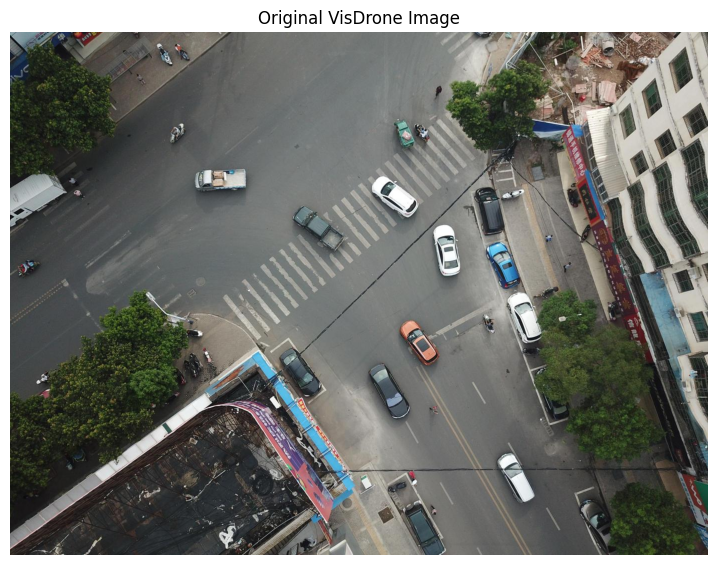

In [73]:
plt.figure(figsize=(9, 9))                                                       # At this point there should be no boxes.
                                                                                 # That's intentional.
plt.imshow(image_rgb)

plt.axis("off")
plt.title("Original VisDrone Image")
plt.show()

## **Draw human bounding boxes**

In [74]:
visualized_image = image_rgb.copy()

for line in annotation_lines:
    values = line.strip().split(",")

    if len(values) < 8:
        continue

    x = int(values[0])
    y = int(values[1])
    width = int(values[2])
    height = int(values[3])
    score = int(values[4])
    category = int(values[5])

    # Keep only valid human annotations
    if score == 1 and category in [1, 2]:
                                                                                 # To calculate botom-right corner
        x2 = x + width                                                           # VisDrone gives us: top-left corner + width + height
        y2 = y + height                                                          # Open CV needs -> top-left + botton-right

        cv2.rectangle(
            visualized_image,
            (x, y),
            (x2, y2),
            (255, 0, 0),
            2
        )

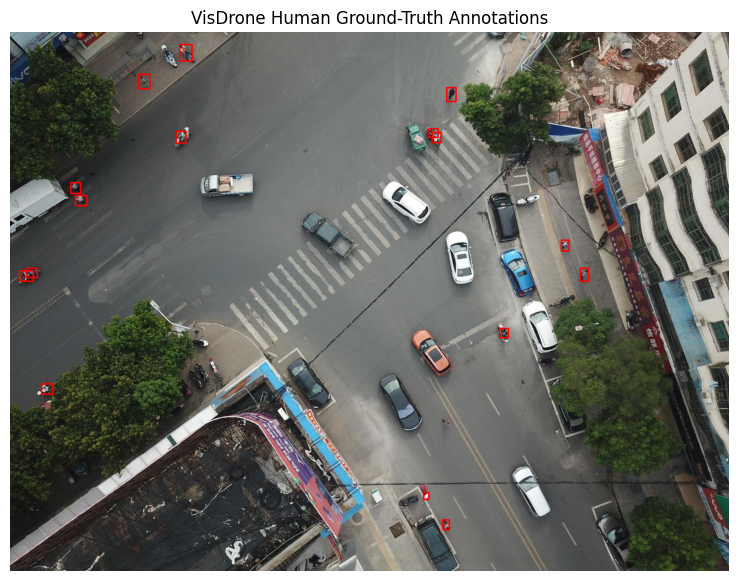

In [75]:
plt.figure(figsize=(12, 7))

plt.imshow(visualized_image)

plt.axis("off")

plt.title("VisDrone Human Ground-Truth Annotations")
plt.show()

In [76]:
human_objects = 0

for line in annotation_lines:

    values = line.strip().split(",")

    if len(values) < 8:
        continue

    score = int(values[4])
    category = int(values[5])

    if score == 1 and category in [1, 2]:

        human_objects += 1

print(
    "Human objects in this image:",
    human_objects
)

Human objects in this image: 16


In [77]:
for i, line in enumerate(annotation_lines):

    values = line.strip().split(",")

    if len(values) < 8:
        continue

    x = int(values[0])
    y = int(values[1])
    width = int(values[2])
    height = int(values[3])

    score = int(values[4])
    category = int(values[5])
    truncation = int(values[6])
    occlusion = int(values[7])

    print(
        f"Object {i}: "
        f"x={x}, y={y}, "
        f"w={width}, h={height}, "
        f"score={score}, "
        f"category={category}, "
        f"truncation={truncation}, "
        f"occlusion={occlusion}"
    )

Object 0: x=842, y=950, w=13, h=19, score=1, category=1, truncation=0, occlusion=0
Object 1: x=805, y=897, w=10, h=13, score=1, category=1, truncation=0, occlusion=0
Object 2: x=953, y=577, w=17, h=18, score=1, category=2, truncation=0, occlusion=0
Object 3: x=1110, y=460, w=16, h=25, score=1, category=1, truncation=0, occlusion=0
Object 4: x=1073, y=405, w=15, h=21, score=1, category=1, truncation=0, occlusion=1
Object 5: x=822, y=195, w=17, h=20, score=1, category=2, truncation=0, occlusion=0
Object 6: x=815, y=188, w=18, h=17, score=1, category=2, truncation=0, occlusion=1
Object 7: x=850, y=108, w=18, h=27, score=1, category=1, truncation=0, occlusion=0
Object 8: x=330, y=24, w=24, h=32, score=1, category=2, truncation=0, occlusion=0
Object 9: x=250, y=82, w=22, h=28, score=1, category=1, truncation=0, occlusion=0
Object 10: x=323, y=193, w=19, h=23, score=1, category=2, truncation=0, occlusion=0
Object 11: x=118, y=293, w=19, h=21, score=1, category=1, truncation=0, occlusion=0
Ob

In [78]:
print("Human-related annotations:\n")

for i, line in enumerate(annotation_lines):

    values = line.strip().split(",")

    if len(values) < 8:
        continue

    x = int(values[0])
    y = int(values[1])
    width = int(values[2])
    height = int(values[3])

    score = int(values[4])
    category = int(values[5])
    truncation = int(values[6])
    occlusion = int(values[7])

    if category in [1, 2]:

        print(
            f"Object {i}: "
            f"x={x}, y={y}, "
            f"w={width}, h={height}, "
            f"score={score}, "
            f"category={category}, "
            f"truncation={truncation}, "
            f"occlusion={occlusion}"
        )

Human-related annotations:

Object 0: x=842, y=950, w=13, h=19, score=1, category=1, truncation=0, occlusion=0
Object 1: x=805, y=897, w=10, h=13, score=1, category=1, truncation=0, occlusion=0
Object 2: x=953, y=577, w=17, h=18, score=1, category=2, truncation=0, occlusion=0
Object 3: x=1110, y=460, w=16, h=25, score=1, category=1, truncation=0, occlusion=0
Object 4: x=1073, y=405, w=15, h=21, score=1, category=1, truncation=0, occlusion=1
Object 5: x=822, y=195, w=17, h=20, score=1, category=2, truncation=0, occlusion=0
Object 6: x=815, y=188, w=18, h=17, score=1, category=2, truncation=0, occlusion=1
Object 7: x=850, y=108, w=18, h=27, score=1, category=1, truncation=0, occlusion=0
Object 8: x=330, y=24, w=24, h=32, score=1, category=2, truncation=0, occlusion=0
Object 9: x=250, y=82, w=22, h=28, score=1, category=1, truncation=0, occlusion=0
Object 10: x=323, y=193, w=19, h=23, score=1, category=2, truncation=0, occlusion=0
Object 11: x=118, y=293, w=19, h=21, score=1, category=1, 

In [79]:
human_all = 0
human_valid = 0
human_ignored = 0

for line in annotation_lines:

    values = line.strip().split(",")

    if len(values) < 8:
        continue

    score = int(values[4])
    category = int(values[5])

    if category in [1, 2]:

        human_all += 1

        if score == 1:
            human_valid += 1

        elif score == 0:
            human_ignored += 1


print("Total human annotations:", human_all)
print("Valid human annotations:", human_valid)
print("Ignored human annotations:", human_ignored)

Total human annotations: 16
Valid human annotations: 16
Ignored human annotations: 0


In [80]:
from collections import Counter

category_counter = Counter()

for line in annotation_lines:

    values = line.strip().split(",")

    if len(values) < 8:
        continue

    category = int(values[5])

    category_counter[category] += 1


print("All categories in this image:")
print(category_counter)

All categories in this image:
Counter({10: 20, 4: 10, 1: 8, 2: 8, 6: 3, 5: 2, 8: 1})


In [81]:
category_names = {
    0: "ignored region",
    1: "pedestrian",
    2: "people",
    3: "bicycle",
    4: "car",
    5: "van",
    6: "truck",
    7: "tricycle",
    8: "awning-tricycle",
    9: "bus",
    10: "motor",
    11: "others"
}

for category, count in sorted(category_counter.items()):

    name = category_names.get(
        category,
        "unknown"
    )

    print(
        f"Category {category}: "
        f"{name} → {count} objects"
    )

Category 1: pedestrian → 8 objects
Category 2: people → 8 objects
Category 4: car → 10 objects
Category 5: van → 2 objects
Category 6: truck → 3 objects
Category 8: awning-tricycle → 1 objects
Category 10: motor → 20 objects


# Define the processed paths

In [82]:
# VISDRONE TO YOLO CONVERSION

PROCESSED_DIR = os.path.join( DATASET_DIR, "Processed", "VisDrone_YOLO" )

YOLO_IMAGES_TRAIN = os.path.join( PROCESSED_DIR, "images", "train" )
YOLO_IMAGES_VAL = os.path.join( PROCESSED_DIR, "images", "val" )

YOLO_LABELS_TRAIN = os.path.join( PROCESSED_DIR, "labels", "train" )
YOLO_LABELS_VAL = os.path.join( PROCESSED_DIR, "labels", "val" )

In [83]:
os.makedirs(
    YOLO_IMAGES_TRAIN,
    exist_ok=True
)

os.makedirs(
    YOLO_IMAGES_VAL,
    exist_ok=True
)

os.makedirs(
    YOLO_LABELS_TRAIN,
    exist_ok=True
)

os.makedirs(
    YOLO_LABELS_VAL,
    exist_ok=True
)

print("YOLO processed directories created successfully\n")
print("Processed dataset structure:\n")

print("Images train:")
print(YOLO_IMAGES_TRAIN)

print("\nImages val:")
print(YOLO_IMAGES_VAL)

print("\nLabels train:")
print(YOLO_LABELS_TRAIN)

print("\nLabels val:")
print(YOLO_LABELS_VAL)

YOLO processed directories created successfully

Processed dataset structure:

Images train:
/content/drive/MyDrive/ResQVision/Datasets/Processed/VisDrone_YOLO/images/train

Images val:
/content/drive/MyDrive/ResQVision/Datasets/Processed/VisDrone_YOLO/images/val

Labels train:
/content/drive/MyDrive/ResQVision/Datasets/Processed/VisDrone_YOLO/labels/train

Labels val:
/content/drive/MyDrive/ResQVision/Datasets/Processed/VisDrone_YOLO/labels/val


In [84]:
import os

image_files = sorted([
    file for file in os.listdir(TRAIN_IMAGES_DIR)
    if file.lower().endswith((".jpg", ".jpeg", ".png"))
])

annotation_files = sorted([
    file for file in os.listdir(TRAIN_ANNOTATIONS_DIR)
    if file.lower().endswith(".txt")
])

print("Total original images:", len(image_files))
print("Total original annotations:", len(annotation_files))

print("\nFirst 5 images:")
print(image_files[:5])

print("\nFirst 5 annotations:")
print(annotation_files[:5])

Total original images: 6471
Total original annotations: 6471

First 5 images:
['0000002_00005_d_0000014.jpg', '0000002_00448_d_0000015.jpg', '0000003_00231_d_0000016.jpg', '0000007_04999_d_0000036.jpg', '0000007_05499_d_0000037.jpg']

First 5 annotations:
['0000002_00005_d_0000014.txt', '0000002_00448_d_0000015.txt', '0000003_00231_d_0000016.txt', '0000007_04999_d_0000036.txt', '0000007_05499_d_0000037.txt']


In [85]:
import os

TEST_ROOT = os.path.join(PROCESSED_DIR, "conversion_test_10")

TEST_IMAGES_DIR = os.path.join(TEST_ROOT, "images")
TEST_LABELS_DIR = os.path.join(TEST_ROOT, "labels")

os.makedirs(TEST_IMAGES_DIR, exist_ok=True)
os.makedirs(TEST_LABELS_DIR, exist_ok=True)

print("Test root:", TEST_ROOT)
print("Test images:", TEST_IMAGES_DIR)
print("Test labels:", TEST_LABELS_DIR)

Test root: /content/drive/MyDrive/ResQVision/Datasets/Processed/VisDrone_YOLO/conversion_test_10
Test images: /content/drive/MyDrive/ResQVision/Datasets/Processed/VisDrone_YOLO/conversion_test_10/images
Test labels: /content/drive/MyDrive/ResQVision/Datasets/Processed/VisDrone_YOLO/conversion_test_10/labels


In [86]:
print("Existing test images:", len(os.listdir(TEST_IMAGES_DIR)))
print("Existing test labels:", len(os.listdir(TEST_LABELS_DIR)))

Existing test images: 10
Existing test labels: 10


In [87]:
import os

test_pairs = []

for image_name in image_files:
    image_stem = os.path.splitext(image_name)[0]
    annotation_name = image_stem + ".txt"
    annotation_path = os.path.join(
        TRAIN_ANNOTATIONS_DIR,
        annotation_name
    )

    if os.path.exists(annotation_path):
        test_pairs.append((image_name, annotation_name))

    if len(test_pairs) == 10:
        break

print("Selected image-annotation pairs:", len(test_pairs))

for image_name, annotation_name in test_pairs:
    print(image_name, "<-->", annotation_name)

Selected image-annotation pairs: 10
0000002_00005_d_0000014.jpg <--> 0000002_00005_d_0000014.txt
0000002_00448_d_0000015.jpg <--> 0000002_00448_d_0000015.txt
0000003_00231_d_0000016.jpg <--> 0000003_00231_d_0000016.txt
0000007_04999_d_0000036.jpg <--> 0000007_04999_d_0000036.txt
0000007_05499_d_0000037.jpg <--> 0000007_05499_d_0000037.txt
0000007_05999_d_0000038.jpg <--> 0000007_05999_d_0000038.txt
0000008_00889_d_0000039.jpg <--> 0000008_00889_d_0000039.txt
0000008_01999_d_0000040.jpg <--> 0000008_01999_d_0000040.txt
0000008_02499_d_0000041.jpg <--> 0000008_02499_d_0000041.txt
0000008_02999_d_0000042.jpg <--> 0000008_02999_d_0000042.txt


### Now we will create a conversion function that:

* Reads only the selected images.
* Reads the matching VisDrone annotation.
* Keeps categories 1 and 2.
* Keeps annotations with score == 1.
* Converts the bounding boxes to YOLO format.
* Copies the image to the test directory.
* Saves its YOLO label file.

In [88]:
import os
import shutil
import cv2


def convert_one_visdrone_image(
    image_name,
    annotation_name,
    input_image_dir,
    input_annotation_dir,
    output_image_dir,
    output_label_dir
):
    # Build the full paths of the input files
    image_path = os.path.join(input_image_dir, image_name)
    annotation_path = os.path.join(input_annotation_dir, annotation_name)

    # Read the image
    image = cv2.imread(image_path)

    if image is None:
        raise ValueError(f"Could not read image: {image_path}")

    # OpenCV returns image dimensions as height, width, channels
    image_height, image_width = image.shape[:2]

    # Store converted YOLO annotations
    yolo_annotations = []

    # Read the original VisDrone annotation file
    with open(annotation_path, "r", encoding="utf-8") as file:
        annotation_lines = file.readlines()

    for line_number, line in enumerate(annotation_lines, start=1):

        # Remove extra spaces and split the line
        values = line.strip().split(",")

        # A standard VisDrone detection annotation has 8 values
        if len(values) != 8:
            print(
                f"Skipping malformed line {line_number} "
                f"in {annotation_name}: {line.strip()}"
            )
            continue

        # Convert values from strings to integers
        x, y, box_width, box_height, score, category, truncation, occlusion = map(
            int,
            values
        )

        # Keep only pedestrian and people categories
        if category not in [1, 2]:
            continue

        # Keep only fully valid annotations
        if score != 1:
            continue

        # Skip invalid bounding boxes
        if box_width <= 0 or box_height <= 0:
            continue

        # Convert VisDrone top-left format to YOLO center format
        center_x = x + (box_width / 2)
        center_y = y + (box_height / 2)

        # Normalize coordinates to the range 0 to 1
        normalized_center_x = center_x / image_width
        normalized_center_y = center_y / image_height
        normalized_width = box_width / image_width
        normalized_height = box_height / image_height

        # Keep boxes within image boundaries
        normalized_center_x = min(max(normalized_center_x, 0), 1)
        normalized_center_y = min(max(normalized_center_y, 0), 1)
        normalized_width = min(max(normalized_width, 0), 1)
        normalized_height = min(max(normalized_height, 0), 1)

        # Both VisDrone categories become YOLO class 0: human
        yolo_class = 0

        # Create one YOLO annotation line
        yolo_line = (
            f"{yolo_class} "
            f"{normalized_center_x:.6f} "
            f"{normalized_center_y:.6f} "
            f"{normalized_width:.6f} "
            f"{normalized_height:.6f}"
        )

        yolo_annotations.append(yolo_line)

    # Copy the image into the test images directory
    output_image_path = os.path.join(output_image_dir, image_name)

    shutil.copy2(image_path, output_image_path)

    # Create the matching label filename
    image_stem = os.path.splitext(image_name)[0]
    output_label_path = os.path.join(
        output_label_dir,
        image_stem + ".txt"
    )

    # Save the YOLO annotations
    with open(output_label_path, "w", encoding="utf-8") as file:
        file.write("\n".join(yolo_annotations))

    return {
        "image_name": image_name,
        "total_annotations": len(annotation_lines),
        "human_annotations": len(yolo_annotations),
        "output_image": output_image_path,
        "output_label": output_label_path
    }

In [89]:
conversion_results = []

for image_name, annotation_name in test_pairs:

    result = convert_one_visdrone_image(
        image_name=image_name,
        annotation_name=annotation_name,
        input_image_dir=TRAIN_IMAGES_DIR,
        input_annotation_dir=TRAIN_ANNOTATIONS_DIR,
        output_image_dir=TEST_IMAGES_DIR,
        output_label_dir=TEST_LABELS_DIR
    )

    conversion_results.append(result)

    print(
        f"Converted: {result['image_name']} | "
        f"Total annotations: {result['total_annotations']} | "
        f"Human annotations: {result['human_annotations']}"
    )

Converted: 0000002_00005_d_0000014.jpg | Total annotations: 88 | Human annotations: 22
Converted: 0000002_00448_d_0000015.jpg | Total annotations: 95 | Human annotations: 32
Converted: 0000003_00231_d_0000016.jpg | Total annotations: 57 | Human annotations: 12
Converted: 0000007_04999_d_0000036.jpg | Total annotations: 59 | Human annotations: 0
Converted: 0000007_05499_d_0000037.jpg | Total annotations: 62 | Human annotations: 0
Converted: 0000007_05999_d_0000038.jpg | Total annotations: 40 | Human annotations: 0
Converted: 0000008_00889_d_0000039.jpg | Total annotations: 14 | Human annotations: 0
Converted: 0000008_01999_d_0000040.jpg | Total annotations: 18 | Human annotations: 0
Converted: 0000008_02499_d_0000041.jpg | Total annotations: 12 | Human annotations: 0
Converted: 0000008_02999_d_0000042.jpg | Total annotations: 47 | Human annotations: 1


Verify number of output files

In [90]:
output_images = [
    file for file in os.listdir(TEST_IMAGES_DIR)
    if file.lower().endswith((".jpg", ".jpeg", ".png"))
]

output_labels = [
    file for file in os.listdir(TEST_LABELS_DIR)
    if file.lower().endswith(".txt")
]

print("Output images:", len(output_images))
print("Output labels:", len(output_labels))

print("\nOutput image files:")
print(sorted(output_images))

print("\nOutput label files:")
print(sorted(output_labels))

Output images: 10
Output labels: 10

Output image files:
['0000002_00005_d_0000014.jpg', '0000002_00448_d_0000015.jpg', '0000003_00231_d_0000016.jpg', '0000007_04999_d_0000036.jpg', '0000007_05499_d_0000037.jpg', '0000007_05999_d_0000038.jpg', '0000008_00889_d_0000039.jpg', '0000008_01999_d_0000040.jpg', '0000008_02499_d_0000041.jpg', '0000008_02999_d_0000042.jpg']

Output label files:
['0000002_00005_d_0000014.txt', '0000002_00448_d_0000015.txt', '0000003_00231_d_0000016.txt', '0000007_04999_d_0000036.txt', '0000007_05499_d_0000037.txt', '0000007_05999_d_0000038.txt', '0000008_00889_d_0000039.txt', '0000008_01999_d_0000040.txt', '0000008_02499_d_0000041.txt', '0000008_02999_d_0000042.txt']


### Validate every YOLO label

In [91]:
import os

invalid_labels = []
total_label_lines = 0

for label_name in sorted(os.listdir(TEST_LABELS_DIR)):

    if not label_name.endswith(".txt"):
        continue

    label_path = os.path.join(TEST_LABELS_DIR, label_name)

    with open(label_path, "r", encoding="utf-8") as file:
        lines = file.readlines()

    for line_number, line in enumerate(lines, start=1):

        values = line.strip().split()

        # Each detection row must contain exactly 5 values
        if len(values) != 5:
            invalid_labels.append(
                f"{label_name}, line {line_number}: wrong number of values"
            )
            continue

        try:
            class_id = int(values[0])
            x_center, y_center, width, height = map(
                float,
                values[1:]
            )
        except ValueError:
            invalid_labels.append(
                f"{label_name}, line {line_number}: non-numeric value"
            )
            continue

        total_label_lines += 1

        # Only class 0 is expected
        if class_id != 0:
            invalid_labels.append(
                f"{label_name}, line {line_number}: invalid class ID"
            )

        # YOLO coordinates must be in the range 0 to 1
        if not all(
            0 <= value <= 1
            for value in [x_center, y_center, width, height]
        ):
            invalid_labels.append(
                f"{label_name}, line {line_number}: coordinate out of range"
            )

        # Width and height must be positive
        if width <= 0 or height <= 0:
            invalid_labels.append(
                f"{label_name}, line {line_number}: invalid dimensions"
            )

print("Total valid label lines:", total_label_lines)
print("Number of validation errors:", len(invalid_labels))

if invalid_labels:
    print("\nFirst validation errors:")
    for error in invalid_labels[:10]:
        print(error)
else:
    print("All YOLO labels passed validation.")

Total valid label lines: 67
Number of validation errors: 0
All YOLO labels passed validation.


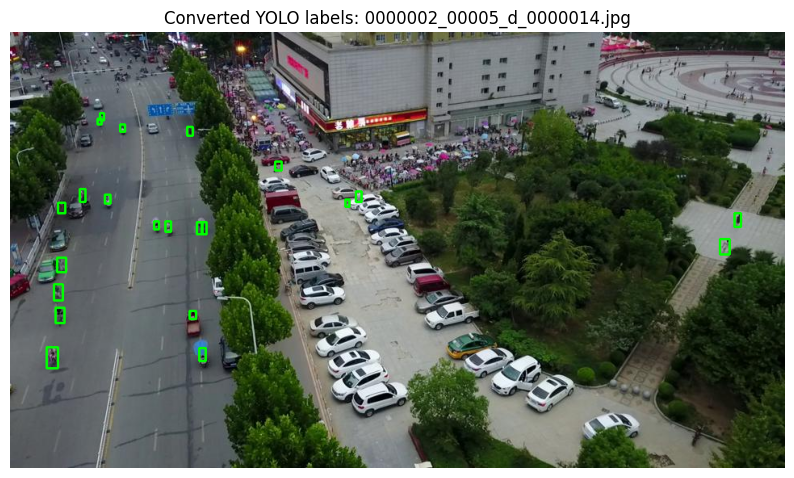

In [92]:
import os
import cv2
import matplotlib.pyplot as plt

# Select the first converted image
sample_image_name = sorted(output_images)[0]

sample_image_path = os.path.join(
    TEST_IMAGES_DIR,
    sample_image_name
)

sample_label_name = os.path.splitext(sample_image_name)[0] + ".txt"

sample_label_path = os.path.join(
    TEST_LABELS_DIR,
    sample_label_name
)

# Read image
image = cv2.imread(sample_image_path)

if image is None:
    raise ValueError("Could not read converted test image.")

# Convert BGR to RGB for Matplotlib
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

image_height, image_width = image.shape[:2]

# Read YOLO labels
with open(sample_label_path, "r", encoding="utf-8") as file:
    label_lines = file.readlines()

for line in label_lines:

    values = line.strip().split()

    if len(values) != 5:
        continue

    class_id, x_center, y_center, box_width, box_height = map(
        float,
        values
    )

    # Convert normalized YOLO coordinates to pixels
    center_x = x_center * image_width
    center_y = y_center * image_height
    width = box_width * image_width
    height = box_height * image_height

    # Convert center coordinates to corner coordinates
    x1 = int(center_x - width / 2)
    y1 = int(center_y - height / 2)
    x2 = int(center_x + width / 2)
    y2 = int(center_y + height / 2)

    # Keep coordinates within image boundaries
    x1 = max(0, min(x1, image_width - 1))
    y1 = max(0, min(y1, image_height - 1))
    x2 = max(0, min(x2, image_width - 1))
    y2 = max(0, min(y2, image_height - 1))

    # Draw bounding box
    cv2.rectangle(
        image,
        (x1, y1),
        (x2, y2),
        (0, 255, 0),
        2
    )

plt.figure(figsize=(10, 10))
plt.imshow(image)
plt.title(f"Converted YOLO labels: {sample_image_name}")
plt.axis("off")
plt.show()

In [95]:
# Get all converted images
corrected_output_images = [
    file
    for file in os.listdir(TEST_IMAGES_DIR)
    if file.lower().endswith((".jpg", ".jpeg", ".png"))
]

# Get all converted label files
corrected_output_labels = [
    file
    for file in os.listdir(TEST_LABELS_DIR)
    if file.lower().endswith(".txt")
]

print("Number of converted images:", len(corrected_output_images))
print("Number of converted labels:", len(corrected_output_labels))

Number of converted images: 10
Number of converted labels: 10


In [99]:
print("Original training images:")
print(TRAIN_IMAGES_DIR)

print("\nOriginal training annotations:")
print(TRAIN_ANNOTATIONS_DIR)

print("\nProcessed training images:")
print(YOLO_IMAGES_TRAIN)

print("\nProcessed training labels:")
print(YOLO_LABELS_TRAIN)

print("\nProcessed root:")
print(PROCESSED_DIR)

Original training images:
/content/drive/MyDrive/ResQVision/Datasets/Raw/VisDrone/Object detection in image/VisDrone2019-DET-train/images

Original training annotations:
/content/drive/MyDrive/ResQVision/Datasets/Raw/VisDrone/Object detection in image/VisDrone2019-DET-train/annotations

Processed training images:
/content/drive/MyDrive/ResQVision/Datasets/Processed/VisDrone_YOLO/images/train

Processed training labels:
/content/drive/MyDrive/ResQVision/Datasets/Processed/VisDrone_YOLO/labels/train

Processed root:
/content/drive/MyDrive/ResQVision/Datasets/Processed/VisDrone_YOLO


In [101]:
existing_train_images = [
    file
    for file in os.listdir(YOLO_IMAGES_TRAIN)
    if file.lower().endswith((".jpg", ".jpeg", ".png"))
]

existing_train_labels = [
    file
    for file in os.listdir(YOLO_LABELS_TRAIN)
    if file.lower().endswith(".txt")
]

print("Existing processed training images:", len(existing_train_images))
print("Existing processed training labels:", len(existing_train_labels))

Existing processed training images: 5684
Existing processed training labels: 5684


### Create separate folders for the complete dataset

For safety, we will use a new folder called full_yolo_dataset.

Earlier 10-image test and the full dataset conversion should not be mixed. This gives us a clean location for the complete dataset.

In [103]:
import os

FULL_YOLO_ROOT = os.path.join(
    PROCESSED_DIR,
    "full_yolo_dataset"
)

FULL_YOLO_IMAGES_TRAIN = os.path.join(
    FULL_YOLO_ROOT,
    "images",
    "train"
)

FULL_YOLO_LABELS_TRAIN = os.path.join(
    FULL_YOLO_ROOT,
    "labels",
    "train"
)

os.makedirs(
    FULL_YOLO_IMAGES_TRAIN,
    exist_ok=True
)

os.makedirs(
    FULL_YOLO_LABELS_TRAIN,
    exist_ok=True
)

print("Full YOLO dataset root:", FULL_YOLO_ROOT)
print("Full training images:", FULL_YOLO_IMAGES_TRAIN)
print("Full training labels:", FULL_YOLO_LABELS_TRAIN)

Full YOLO dataset root: /content/drive/MyDrive/ResQVision/Datasets/Processed/VisDrone_YOLO/full_yolo_dataset
Full training images: /content/drive/MyDrive/ResQVision/Datasets/Processed/VisDrone_YOLO/full_yolo_dataset/images/train
Full training labels: /content/drive/MyDrive/ResQVision/Datasets/Processed/VisDrone_YOLO/full_yolo_dataset/labels/train


In [105]:
import os


def convert_complete_dataset(
    input_image_dir,
    input_annotation_dir,
    output_image_dir,
    output_label_dir
):
    # Get all image files from the source directory
    image_files = sorted([
        file
        for file in os.listdir(input_image_dir)
        if file.lower().endswith(
            (".jpg", ".jpeg", ".png")
        )
    ])

    print("Total source images:", len(image_files))

    converted_count = 0
    skipped_count = 0
    total_human_annotations = 0

    for index, image_name in enumerate(
        image_files,
        start=1
    ):

        # Create the expected annotation filename
        image_stem = os.path.splitext(image_name)[0]

        annotation_name = image_stem + ".txt"

        annotation_path = os.path.join(
            input_annotation_dir,
            annotation_name
        )

        # Skip the image if its annotation is missing
        if not os.path.exists(annotation_path):

            skipped_count += 1

            print(
                f"Skipping {image_name}: "
                "annotation not found"
            )

            continue

        # Convert one image using the corrected function
        result = convert_one_visdrone_image(
            image_name=image_name,
            annotation_name=annotation_name,
            input_image_dir=input_image_dir,
            input_annotation_dir=input_annotation_dir,
            output_image_dir=output_image_dir,
            output_label_dir=output_label_dir
        )

        converted_count += 1

        total_human_annotations += (
            result["human_annotations"]
        )

        # Print progress periodically
        if index % 500 == 0 or index == len(image_files):

            print(
                f"Progress: {index}/{len(image_files)} | "
                f"Converted: {converted_count} | "
                f"Skipped: {skipped_count} | "
                f"Human annotations: "
                f"{total_human_annotations}"
            )
    print(
        "Total source images:",
        len(image_files)
    )

    print(
        "Successfully converted:",
        converted_count
    )

    print(
        "Skipped images:",
        skipped_count
    )

    print( "Total human annotations:", total_human_annotations)

    return {
        "source_images": len(image_files),
        "converted_images": converted_count,
        "skipped_images": skipped_count,
        "human_annotations": total_human_annotations
    }

In [106]:
training_conversion_summary = convert_complete_dataset(
    input_image_dir=TRAIN_IMAGES_DIR,
    input_annotation_dir=TRAIN_ANNOTATIONS_DIR,
    output_image_dir=FULL_YOLO_IMAGES_TRAIN,
    output_label_dir=FULL_YOLO_LABELS_TRAIN
)

Total source images: 6471
Progress: 500/6471 | Converted: 500 | Skipped: 0 | Human annotations: 19430
Progress: 1000/6471 | Converted: 1000 | Skipped: 0 | Human annotations: 26818
Progress: 1500/6471 | Converted: 1500 | Skipped: 0 | Human annotations: 38644
Progress: 2000/6471 | Converted: 2000 | Skipped: 0 | Human annotations: 46254
Progress: 2500/6471 | Converted: 2500 | Skipped: 0 | Human annotations: 52426
Progress: 3000/6471 | Converted: 3000 | Skipped: 0 | Human annotations: 56598
Progress: 3500/6471 | Converted: 3500 | Skipped: 0 | Human annotations: 64591
Progress: 4000/6471 | Converted: 4000 | Skipped: 0 | Human annotations: 70095
Progress: 4500/6471 | Converted: 4500 | Skipped: 0 | Human annotations: 77183
Skipping malformed line 1 in 9999974_00000_d_0000053.txt: 440,541,271,152,1,6,0,0,
Skipping malformed line 2 in 9999974_00000_d_0000053.txt: 436,772,134,72,1,5,0,0,
Skipping malformed line 3 in 9999974_00000_d_0000053.txt: 601,713,60,39,1,10,0,0,
Skipping malformed line 4 i